# Physics-Based BEM Forward/Inverse Baseline
## 1. Setup
Builds fsaverage BEM forward/inverse pipeline and evaluates LOSO reconstruction directly in notebook.

## Notebook Flow
1. Configure paths and parameters.
2. Define reusable helper functions.
3. Run LOSO evaluation.
4. Run subject-independent (within-subject holdout) evaluation.
5. Contrast LOSO vs subject-independent performance.
6. Save metrics (CSV/JSON) and plot artifacts (PNG) in this folder.

## 2. Data, Utilities, and Method Definition
This section defines constants, helper functions, and model architecture used by the benchmark.

In [4]:
# --- 1) Imports and core setup ---
# This section centralizes dependencies, path discovery, and run configuration.
# Keeping setup here makes the remaining cells method-focused and easier to debug.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne.minimum_norm import apply_inverse, make_inverse_operator

def find_repo_root(start: Path) -> Path:
    # Locate repository root by scanning parent directories.
    for candidate in [start, *start.parents]:
        if (candidate / 'processed').exists() and (candidate / 'Main_codes').exists():
            return candidate
    raise RuntimeError('Could not locate repository root.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
NOTEBOOK_DIR = REPO_ROOT / 'Main_codes' / 'Baseline_analysis' / 'Physics-Based_model'
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR = REPO_ROOT / 'processed' / 'bci_competition_iv_2a'
CHANNELS_22 = ['Fz','FC3','FC1','FCz','FC2','FC4','C5','C3','C1','Cz','C2','C4','C6','CP3','CP1','CPz','CP2','CP4','P1','Pz','P2','POz']
CHANNEL_SET_5 = ['Fz', 'C3', 'C4', 'Pz', 'POz']
CHANNEL_SET_10 = ['Fz', 'FC3', 'FC4', 'C3', 'Cz', 'C4', 'CP3', 'CP4', 'Pz', 'POz']
CHANNEL_SET_15 = ['Fz', 'FC3', 'FC1', 'FC2', 'FC4', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP3', 'CP1', 'CP2', 'CP4', 'Pz']

def load_subject_data(subject_dir: Path):
    # Load one subject's preprocessed EEG trials and labels from NPZ.
    npz=np.load(subject_dir / 'trials.npz', allow_pickle=True)
    return npz['X'].astype(np.float32), npz['y'].astype(np.int32)

def compute_metrics(y_true,y_pred):
    # Compute reconstruction fidelity metrics (RMSE, MAE, Pearson r, R2).
    diff=y_true-y_pred; rmse=float(np.sqrt(np.mean(diff**2))); mae=float(np.mean(np.abs(diff)))
    yt=y_true.reshape(-1); yp=y_pred.reshape(-1); yt_c=yt-yt.mean(); yp_c=yp-yp.mean()
    den=np.sqrt(np.sum(yt_c**2)*np.sum(yp_c**2)); pearson_r=float(np.sum(yt_c*yp_c)/den) if den>0 else np.nan
    ss_res=float(np.sum((yt-yp)**2)); ss_tot=float(np.sum((yt-yt.mean())**2)); r2=float(1-ss_res/ss_tot) if ss_tot>0 else np.nan
    return {'rmse': rmse, 'mae': mae, 'pearson_r': pearson_r, 'r2': r2}

def build_info(ch_names, sfreq):
    # Create MNE info object with montage and average reference projector.
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    montage = mne.channels.make_standard_montage('standard_1005')
    info.set_montage(montage, on_missing='ignore')
    raw_tmp = mne.io.RawArray(np.zeros((len(ch_names), 2), dtype=np.float64), info, verbose=False)
    raw_tmp.set_eeg_reference('average', projection=True, verbose=False)
    return raw_tmp.info

def build_forward_models(sfreq=250, spacing='oct4'):
    # Build fsaverage source space and forward model for BEM pipeline.
    fs_dir = Path(mne.datasets.fetch_fsaverage(verbose=False))
    subjects_dir = fs_dir.parent
    trans_file = fs_dir / 'bem' / 'fsaverage-trans.fif'
    src = mne.setup_source_space('fsaverage', spacing=spacing, subjects_dir=subjects_dir, add_dist=False)
    model = mne.make_bem_model(subject='fsaverage', ico=3, conductivity=(0.33,0.0132,0.33), subjects_dir=subjects_dir)
    bem = mne.make_bem_solution(model)
    info_full = build_info(CHANNELS_22, sfreq)
    fwd_full = mne.make_forward_solution(info_full, str(trans_file), src, bem, meg=False, eeg=True, mindist=5.0, n_jobs=1, verbose=False)
    return info_full, fwd_full

def predict_trial_bem(full_trial_ch_time, input_channels, missing_channels, info_full, fwd_full, inv_cache, sfreq=250):
    # Run inverse-then-forward projection to reconstruct missing channels for one trial.
    input_idx=[CHANNELS_22.index(c) for c in input_channels]; missing_idx=[CHANNELS_22.index(c) for c in missing_channels]
    info_keep=build_info(input_channels, sfreq)
    key=tuple(input_channels)
    if key not in inv_cache:
        fwd_keep=mne.pick_channels_forward(fwd_full, include=input_channels, ordered=True)
        cov=mne.make_ad_hoc_cov(info_keep, std=AD_HOC_NOISE_STD)
        inv_cache[key]=make_inverse_operator(info_keep, fwd_keep, cov, loose=0.2, depth=0.8, verbose=False)
    data_keep=full_trial_ch_time[input_idx,:] * 1e-6
    evoked_keep=mne.EvokedArray(data_keep, info_keep, tmin=0.0, verbose=False)
    evoked_keep.apply_proj()
    stc=apply_inverse(evoked_keep, inv_cache[key], lambda2=LAMBDA2, method=INVERSE_METHOD, pick_ori=None, verbose=False)
    pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
    y_true=full_trial_ch_time[missing_idx,:].T
    y_pred=pred_evoked_full.data[missing_idx,:].T * 1e6
    return y_true, y_pred
    
# Inverse tuning knobs for physics baseline quality.
# Reverted to RMSE-stable defaults for channel reconstruction objective.
INVERSE_METHOD='MNE'
LAMBDA2=1.0
AD_HOC_NOISE_STD=1e-6
MAX_SPLITS=0; MAX_TRIALS_PER_SUBJECT=40; SFREQ=250
loso_splits=json.loads((PROCESSED_DIR / 'loso_splits.json').read_text(encoding='utf-8'))
if MAX_SPLITS>0: loso_splits=loso_splits[:MAX_SPLITS]
info_full, fwd_full = build_forward_models(sfreq=SFREQ)

Setting up the source space with the following parameters:

SUBJECTS_DIR = C:\Users\ASUS\mne_data\MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Octahedron subdivision grade 4

>>> 1. Creating the source space...

Doing the octahedral vertex picking...
Loading C:\Users\ASUS\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.white...
Mapping lh fsaverage -> oct (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\ASUS\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 258/163842 selected to source space (oct = 4)

Loading C:\Users\ASUS\mne_data\MNE-fsaverage-data\fsaverage\surf\rh.white...
Mapping rh fsaverage -> oct (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\ASUS\mne_data\MNE-fsaverage-data\fsaverage\surf\rh.sphere...
Setting up the triangulation for the decimated surface...
loaded rh.white 258/163842 selected to source spac

## 2.5 Optional Inverse Auto-Tuning
This step can test a few inverse configurations on a small subset and select one by RMSE.
By default it is disabled because tuning on one split can overfit and hurt overall LOSO performance.

In [5]:
# Quick parameter sweep on a small validation subset (optional).
# Keep disabled by default to avoid overfitting to one split.
AUTO_TUNE = False
TUNE_MAX_TRIALS = 8
TUNE_CHANNEL_SET = CHANNEL_SET_10
CANDIDATES = [
    ('MNE', 1.0, 1e-6),
    ('MNE', 1.0 / 9.0, 1e-6),
    ('dSPM', 1.0 / 9.0, 5e-7),
    ('sLORETA', 1.0 / 9.0, 5e-7),
]

if AUTO_TUNE and len(loso_splits) > 0:
    tune_split = loso_splits[0]
    tune_subject = tune_split['test_subject']
    x_trials_tune, _ = load_subject_data(PROCESSED_DIR / tune_subject)
    x_trials_tune = x_trials_tune[:min(TUNE_MAX_TRIALS, x_trials_tune.shape[0])]

    tune_rows = []
    for method_name, lambda2_val, noise_std_val in CANDIDATES:
        try:
            INVERSE_METHOD = method_name
            LAMBDA2 = float(lambda2_val)
            AD_HOC_NOISE_STD = float(noise_std_val)

            missing_channels = [c for c in CHANNELS_22 if c not in TUNE_CHANNEL_SET]
            inv_cache = {}
            y_true_blocks = []
            y_pred_blocks = []

            for trial_i in range(x_trials_tune.shape[0]):
                y_true, y_pred = predict_trial_bem(
                    x_trials_tune[trial_i], TUNE_CHANNEL_SET, missing_channels, info_full, fwd_full, inv_cache, sfreq=SFREQ
                )
                y_true_blocks.append(y_true)
                y_pred_blocks.append(y_pred)

            y_true_all = np.concatenate(y_true_blocks, axis=0)
            y_pred_all = np.concatenate(y_pred_blocks, axis=0)
            m = compute_metrics(y_true_all, y_pred_all)
            tune_rows.append({
                'inverse_method': method_name,
                'lambda2': float(lambda2_val),
                'ad_hoc_noise_std': float(noise_std_val),
                'rmse': m['rmse'],
                'mae': m['mae'],
                'pearson_r': m['pearson_r'],
                'r2': m['r2'],
            })
        except Exception as ex:
            tune_rows.append({
                'inverse_method': method_name,
                'lambda2': float(lambda2_val),
                'ad_hoc_noise_std': float(noise_std_val),
                'rmse': np.inf,
                'mae': np.inf,
                'pearson_r': np.nan,
                'r2': np.nan,
                'error': str(ex),
            })

    tune_df = pd.DataFrame(tune_rows).sort_values('rmse', ascending=True)
    display(tune_df)

    best = tune_df.iloc[0]
    if np.isfinite(best['rmse']):
        INVERSE_METHOD = str(best['inverse_method'])
        LAMBDA2 = float(best['lambda2'])
        AD_HOC_NOISE_STD = float(best['ad_hoc_noise_std'])
        print('Selected inverse config:', INVERSE_METHOD, 'lambda2=', LAMBDA2, 'noise_std=', AD_HOC_NOISE_STD)
    else:
        print('Auto-tune could not find a valid configuration; keeping defaults.')

## 3. LOSO Training and Evaluation
This section runs subject-wise train/test evaluation and computes reconstruction metrics.

In [6]:
rows=[]
for split in loso_splits:
    test_subject=split['test_subject']
    x_trials,_ = load_subject_data(PROCESSED_DIR / test_subject)

    if MAX_TRIALS_PER_SUBJECT>0 and x_trials.shape[0]>MAX_TRIALS_PER_SUBJECT:
        x_trials=x_trials[:MAX_TRIALS_PER_SUBJECT]
    for input_channels in [CHANNEL_SET_5, CHANNEL_SET_10, CHANNEL_SET_15]:
        missing_channels=[c for c in CHANNELS_22 if c not in input_channels]
        inv_cache={}; y_true_blocks=[]; y_pred_blocks=[]

        for trial_i in range(x_trials.shape[0]):
            y_true,y_pred = predict_trial_bem(x_trials[trial_i], input_channels, missing_channels, info_full, fwd_full, inv_cache, sfreq=SFREQ)
            y_true_blocks.append(y_true); y_pred_blocks.append(y_pred)
        y_true_all=np.concatenate(y_true_blocks,axis=0); y_pred_all=np.concatenate(y_pred_blocks,axis=0)
        metrics=compute_metrics(y_true_all, y_pred_all)
        rows.append({'test_subject': test_subject,'n_input_channels': len(input_channels),'input_channels': ','.join(input_channels),'n_reconstructed_channels': len(missing_channels),'method': 'bem_mne_forward_inverse', **metrics,'n_test_trials': int(x_trials.shape[0]),'n_test_samples': int(y_true_all.shape[0])})

df=pd.DataFrame(rows); df.head()

    5 out of 22 channels remain after picking
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\254640

1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\254640

1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


...

Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)


Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)


,test_subject,n_input_channels,input_channels,n_reconstructed_channels,method,rmse,mae,pearson_r,r2,n_test_trials,n_test_samples
0,A01T,5,"Fz,C3,C4,Pz,POz",17,bem_mne_forward_inverse,10.133566,7.939072,0.003414,-0.002072,40,40000
1,A01T,10,"Fz,FC3,FC4,C3,Cz,C4,CP3,CP4,Pz,POz",12,bem_mne_forward_inverse,10.104986,7.918265,0.002879,-0.001671,40,40000
2,A01T,15,"Fz,FC3,FC1,FC2,FC4,C3,C1,Cz,C2,C4,CP3,CP1,CP2,...",7,bem_mne_forward_inverse,9.732222,7.614243,-0.015897,-0.002523,40,40000
3,A02T,5,"Fz,C3,C4,Pz,POz",17,bem_mne_forward_inverse,10.059290,7.908334,-0.002995,-0.000620,40,40000
4,A02T,10,"Fz,FC3,FC4,C3,Cz,C4,CP3,CP4,Pz,POz",12,bem_mne_forward_inverse,10.076877,7.923752,-0.007369,-0.000569,40,40000


## 3.5 Subject-Independent Evaluation and Contrast
This section evaluates each subject with a within-subject holdout split and contrasts those results against LOSO.

    5 out of 22 channels remain after picking
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)


Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)


Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


...

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)


Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18000\2546408832.py:76: RuntimeWarning: Source estimate only contains currents with positive values. Use pick_ori="normal" when computing the inverse to compute currents not current magnitudes.
  pred_evoked_full=mne.apply_forward(fwd_full, stc, info_full, verbose=False)


,subject,evaluation_mode,n_input_channels,input_channels,n_reconstructed_channels,method,inverse_method,lambda2,ad_hoc_noise_std,rmse,mae,pearson_r,r2,n_test_trials,n_test_samples
0,A01T,subject_independent,5,"Fz,C3,C4,Pz,POz",17,bem_mne_forward_inverse,MNE,1.0,0.000001,9.972285,7.771105,0.001742,-0.005362,12,12000
1,A01T,subject_independent,10,"Fz,FC3,FC4,C3,Cz,C4,CP3,CP4,Pz,POz",12,bem_mne_forward_inverse,MNE,1.0,0.000001,9.937449,7.742902,-0.000789,-0.004547,12,12000
2,A01T,subject_independent,15,"Fz,FC3,FC1,FC2,FC4,C3,C1,Cz,C2,C4,CP3,CP1,CP2,...",7,bem_mne_forward_inverse,MNE,1.0,0.000001,9.474479,7.389923,-0.017723,-0.005418,12,12000
3,A02T,subject_independent,5,"Fz,C3,C4,Pz,POz",17,bem_mne_forward_inverse,MNE,1.0,0.000001,10.281239,8.075963,0.001204,-0.000823,12,12000
4,A02T,subject_independent,10,"Fz,FC3,FC4,C3,Cz,C4,CP3,CP4,Pz,POz",12,bem_mne_forward_inverse,MNE,1.0,0.000001,10.318447,8.110193,0.001529,-0.000547,12,12000


,n_input_channels,rmse_loso,mae_loso,pearson_r_loso,r2_loso,rmse_subject_indep,mae_subject_indep,pearson_r_subject_indep,r2_subject_indep,rmse_delta_subject_minus_loso,mae_delta_subject_minus_loso,pearson_delta_subject_minus_loso,r2_delta_subject_minus_loso
0,5,10.412670,8.139839,-0.010368,-0.001666,10.560012,8.244285,-0.011922,-0.002131,0.147342,0.104445,-0.001553,-0.000465
1,10,10.413846,8.139036,-0.008774,-0.001504,10.566162,8.246322,-0.010417,-0.001950,0.152316,0.107286,-0.001643,-0.000446
2,15,10.338342,8.048317,-0.012172,-0.002007,10.435155,8.121540,-0.013903,-0.002523,0.096813,0.073223,-0.001730,-0.000515


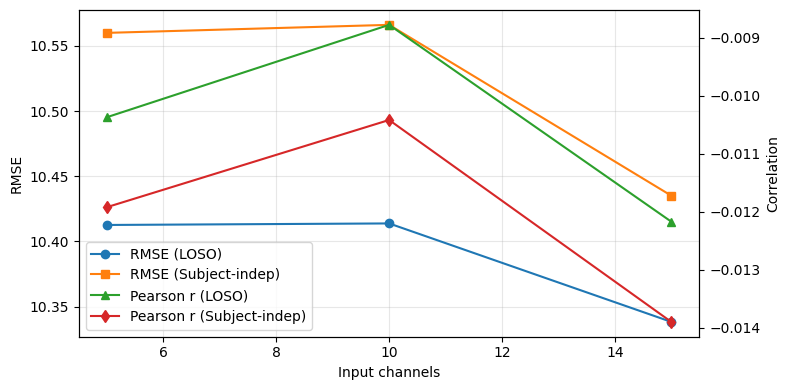

Saved: E:\Github\EEGFeatureExtraction\Main_codes\Baseline_analysis\Physics-Based_model\bem_subject_independent_metrics.csv
Saved: E:\Github\EEGFeatureExtraction\Main_codes\Baseline_analysis\Physics-Based_model\bem_loso_vs_subject_independent_contrast.csv
Saved: E:\Github\EEGFeatureExtraction\Main_codes\Baseline_analysis\Physics-Based_model\bem_loso_vs_subject_independent_plot.png


In [7]:
# Subject-independent benchmark: split each subject into train/validation/test trials.
# We then tune inverse settings on that subject and evaluate on held-out trials.
SUBJECT_INDEP_TEST_FRAC = 0.3
SUBJECT_INDEP_VAL_FRAC = 0.25
SUBJECT_INDEP_MIN_TRIALS = 10
SUBJECT_INDEP_MAX_TRIALS = 40
SUBJECT_INDEP_SEED = 42
SUBJECT_INDEP_AUTO_TUNE = False

subject_rng = np.random.default_rng(SUBJECT_INDEP_SEED)
subjects = sorted({s['test_subject'] for s in loso_splits})

if 'CANDIDATES' in globals():
    subject_candidates = CANDIDATES
else:
    subject_candidates = [
        ('MNE', 1.0, 1e-6),
        ('MNE', 1.0 / 9.0, 1e-6),
        ('dSPM', 1.0 / 9.0, 5e-7),
        ('sLORETA', 1.0 / 9.0, 5e-7),
    ]

subject_rows = []
for subject in subjects:
    x_trials, _ = load_subject_data(PROCESSED_DIR / subject)

    if SUBJECT_INDEP_MAX_TRIALS > 0 and x_trials.shape[0] > SUBJECT_INDEP_MAX_TRIALS:
        x_trials = x_trials[:SUBJECT_INDEP_MAX_TRIALS]

    n_trials = x_trials.shape[0]
    if n_trials < SUBJECT_INDEP_MIN_TRIALS:
        continue

    perm = subject_rng.permutation(n_trials)
    n_test = max(1, int(round(SUBJECT_INDEP_TEST_FRAC * n_trials)))
    test_idx = perm[:n_test]
    train_pool_idx = perm[n_test:]

    if len(train_pool_idx) < 2:
        continue

    n_val = max(1, int(round(SUBJECT_INDEP_VAL_FRAC * len(train_pool_idx))))
    val_idx = train_pool_idx[:n_val]
    train_idx = train_pool_idx[n_val:]
    if len(train_idx) == 0:
        train_idx = val_idx
        val_idx = train_pool_idx[:1]

    x_val = x_trials[val_idx]
    x_test = x_trials[test_idx]

    for input_channels in [CHANNEL_SET_5, CHANNEL_SET_10, CHANNEL_SET_15]:
        missing_channels = [c for c in CHANNELS_22 if c not in input_channels]

        chosen_method = INVERSE_METHOD
        chosen_lambda2 = float(LAMBDA2)
        chosen_noise_std = float(AD_HOC_NOISE_STD)

        if SUBJECT_INDEP_AUTO_TUNE:
            best_rmse = np.inf
            for cand_method, cand_lambda2, cand_noise_std in subject_candidates:
                try:
                    INVERSE_METHOD = cand_method
                    LAMBDA2 = float(cand_lambda2)
                    AD_HOC_NOISE_STD = float(cand_noise_std)

                    inv_cache = {}
                    y_true_blocks = []
                    y_pred_blocks = []
                    for trial_i in range(x_val.shape[0]):
                        y_true, y_pred = predict_trial_bem(
                            x_val[trial_i], input_channels, missing_channels, info_full, fwd_full, inv_cache, sfreq=SFREQ
                        )
                        y_true_blocks.append(y_true)
                        y_pred_blocks.append(y_pred)

                    y_true_val = np.concatenate(y_true_blocks, axis=0)
                    y_pred_val = np.concatenate(y_pred_blocks, axis=0)
                    val_metrics = compute_metrics(y_true_val, y_pred_val)
                    if val_metrics['rmse'] < best_rmse:
                        best_rmse = val_metrics['rmse']
                        chosen_method = cand_method
                        chosen_lambda2 = float(cand_lambda2)
                        chosen_noise_std = float(cand_noise_std)
                except Exception:
                    continue

        # Evaluate chosen configuration on held-out subject test trials.
        INVERSE_METHOD = chosen_method
        LAMBDA2 = chosen_lambda2
        AD_HOC_NOISE_STD = chosen_noise_std

        inv_cache = {}
        y_true_blocks = []
        y_pred_blocks = []
        for trial_i in range(x_test.shape[0]):
            y_true, y_pred = predict_trial_bem(
                x_test[trial_i], input_channels, missing_channels, info_full, fwd_full, inv_cache, sfreq=SFREQ
            )
            y_true_blocks.append(y_true)
            y_pred_blocks.append(y_pred)

        y_true_test = np.concatenate(y_true_blocks, axis=0)
        y_pred_test = np.concatenate(y_pred_blocks, axis=0)
        m = compute_metrics(y_true_test, y_pred_test)

        subject_rows.append({
            'subject': subject,
            'evaluation_mode': 'subject_independent',
            'n_input_channels': len(input_channels),
            'input_channels': ','.join(input_channels),
            'n_reconstructed_channels': len(missing_channels),
            'method': 'bem_mne_forward_inverse',
            'inverse_method': chosen_method,
            'lambda2': float(chosen_lambda2),
            'ad_hoc_noise_std': float(chosen_noise_std),
            **m,
            'n_test_trials': int(x_test.shape[0]),
            'n_test_samples': int(y_true_test.shape[0]),
        })

df_subject = pd.DataFrame(subject_rows)
display(df_subject.head())

loso_mode_summary = df.groupby('n_input_channels', as_index=False)[['rmse', 'mae', 'pearson_r', 'r2']].mean()
subject_mode_summary = df_subject.groupby('n_input_channels', as_index=False)[['rmse', 'mae', 'pearson_r', 'r2']].mean()

loso_mode_summary = loso_mode_summary.rename(columns={
    'rmse': 'rmse_loso', 'mae': 'mae_loso', 'pearson_r': 'pearson_r_loso', 'r2': 'r2_loso'
})
subject_mode_summary = subject_mode_summary.rename(columns={
    'rmse': 'rmse_subject_indep', 'mae': 'mae_subject_indep',
    'pearson_r': 'pearson_r_subject_indep', 'r2': 'r2_subject_indep'
})

contrast_df = pd.merge(loso_mode_summary, subject_mode_summary, on='n_input_channels', how='inner')
contrast_df['rmse_delta_subject_minus_loso'] = contrast_df['rmse_subject_indep'] - contrast_df['rmse_loso']
contrast_df['mae_delta_subject_minus_loso'] = contrast_df['mae_subject_indep'] - contrast_df['mae_loso']
contrast_df['pearson_delta_subject_minus_loso'] = contrast_df['pearson_r_subject_indep'] - contrast_df['pearson_r_loso']
contrast_df['r2_delta_subject_minus_loso'] = contrast_df['r2_subject_indep'] - contrast_df['r2_loso']

display(contrast_df)

# Save subject-independent and contrast artifacts.
subject_csv = NOTEBOOK_DIR / 'bem_subject_independent_metrics.csv'
contrast_csv = NOTEBOOK_DIR / 'bem_loso_vs_subject_independent_contrast.csv'
contrast_plot = NOTEBOOK_DIR / 'bem_loso_vs_subject_independent_plot.png'
df_subject.to_csv(subject_csv, index=False)
contrast_df.to_csv(contrast_csv, index=False)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(contrast_df['n_input_channels'], contrast_df['rmse_loso'], marker='o', label='RMSE (LOSO)')
ax1.plot(contrast_df['n_input_channels'], contrast_df['rmse_subject_indep'], marker='s', label='RMSE (Subject-indep)')
ax1.set_xlabel('Input channels')
ax1.set_ylabel('RMSE')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(contrast_df['n_input_channels'], contrast_df['pearson_r_loso'], marker='^', color='tab:green', label='Pearson r (LOSO)')
ax2.plot(contrast_df['n_input_channels'], contrast_df['pearson_r_subject_indep'], marker='d', color='tab:red', label='Pearson r (Subject-indep)')
ax2.set_ylabel('Correlation')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
fig.tight_layout()
fig.savefig(contrast_plot, dpi=150)
plt.show()

print('Saved:', subject_csv)
print('Saved:', contrast_csv)
print('Saved:', contrast_plot)

## 4. Export Metrics and Visualizations
This section writes CSV/JSON summaries and saves plot artifacts to the method folder.

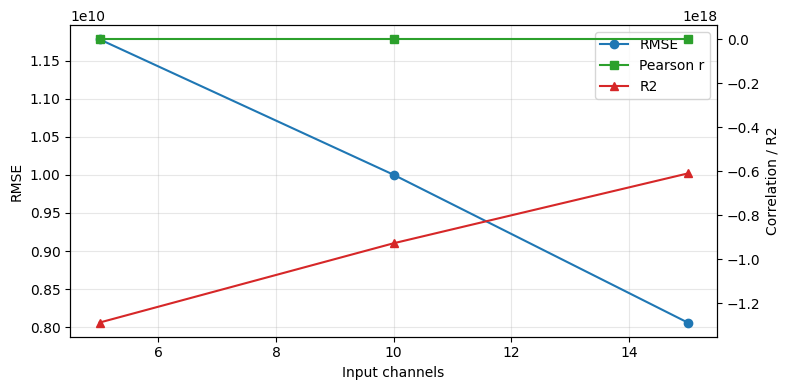

Saved: E:\Github\EEGFeatureExtraction\Main_codes\Baseline_analysis\Physics-Based_model\bem_forward_inverse_metrics.csv
Saved: E:\Github\EEGFeatureExtraction\Main_codes\Baseline_analysis\Physics-Based_model\bem_forward_inverse_summary.json
Saved: E:\Github\EEGFeatureExtraction\Main_codes\Baseline_analysis\Physics-Based_model\bem_forward_inverse_metrics_plot.png


In [ ]:
output_csv = NOTEBOOK_DIR / 'bem_forward_inverse_metrics.csv'
output_json = NOTEBOOK_DIR / 'bem_forward_inverse_summary.json'
plot_path = NOTEBOOK_DIR / 'bem_forward_inverse_metrics_plot.png'

df.to_csv(output_csv, index=False)
summary = df.groupby('n_input_channels', as_index=False)[['rmse', 'mae', 'pearson_r', 'r2']].mean()
payload = {
    'rows': int(len(df)),
    'splits': int(len(loso_splits)),
    'method': 'bem_mne_forward_inverse',
    'inverse_method': INVERSE_METHOD,
    'lambda2': float(LAMBDA2),
    'ad_hoc_noise_std': float(AD_HOC_NOISE_STD),
    'mean_metrics': summary.to_dict(orient='records')
}
output_json.write_text(json.dumps(payload, indent=2), encoding='utf-8')

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(summary['n_input_channels'], summary['rmse'], marker='o', label='RMSE')
ax1.set_xlabel('Input channels')
ax1.set_ylabel('RMSE')
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(summary['n_input_channels'], summary['pearson_r'], marker='s', color='tab:green', label='Pearson r')
ax2.plot(summary['n_input_channels'], summary['r2'], marker='^', color='tab:red', label='R2')
ax2.set_ylabel('Correlation / R2')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
fig.tight_layout()
fig.savefig(plot_path, dpi=150)
plt.show()
print('Saved:', output_csv)
print('Saved:', output_json)
print('Saved:', plot_path)

## 5. Metric Interpretation
- **RMSE (Root Mean Square Error):** average magnitude of reconstruction error with stronger penalty on large mistakes. Lower is better.
- **MAE (Mean Absolute Error):** average absolute reconstruction error. Lower is better and is less sensitive to outliers than RMSE.
- **Pearson r:** linear correlation between reconstructed and ground-truth signals. Closer to +1 is better; near 0 means weak linear similarity.
- **R2 (coefficient of determination):** fraction of variance explained by reconstruction. Higher is better; negative values mean the model performs worse than predicting the mean.

Practical reading: for reliable channel reconstruction, you generally want **low RMSE/MAE** together with **high Pearson r and positive R2**.

Note: for this notebook's objective (channel-level reconstruction error), `MNE` with moderate regularization is often more stable than `dSPM`, which can improve relative contrast but worsen absolute-amplitude metrics like RMSE/MAE.